In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Mounted at /content/drive


# **Data Preprocessing**

In [26]:
from sklearn.model_selection import train_test_split

# Create numeric labels
label_map = {"negative": 0, "neutral": 1, "positive": 2}
train_df["label"] = train_df["customer_sentiment"].map(label_map)

# Split only train.csv into train and validation
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["customer_sentiment"]
)

print("Train split shape:", train_split_df.shape)
print("Validation split shape:", val_split_df.shape)

print("\nTrain split sentiment distribution:")
print(train_split_df["customer_sentiment"].value_counts())

print("\nValidation split sentiment distribution:")
print(val_split_df["customer_sentiment"].value_counts())

base_path = "/content/drive/MyDrive/DI725_assignment1_dataset"

train_split_path = f"{base_path}/train_split.csv"
val_split_path = f"{base_path}/val_split.csv"

train_split_df.to_csv(train_split_path, index=False)
val_split_df.to_csv(val_split_path, index=False)

print("Saved:")
print(train_split_path)
print(val_split_path)

Train split shape: (873, 12)
Validation split shape: (97, 12)

Train split sentiment distribution:
customer_sentiment
neutral     488
negative    370
positive     15
Name: count, dtype: int64

Validation split sentiment distribution:
customer_sentiment
neutral     54
negative    41
positive     2
Name: count, dtype: int64
Saved:
/content/drive/MyDrive/DI725_assignment1_dataset/train_split.csv
/content/drive/MyDrive/DI725_assignment1_dataset/val_split.csv


In [ ]:
def plot_sentiment_distribution(df, title, label_col="customer_sentiment"):
    class_counts = df[label_col].value_counts()

    print(f"\n{title} class distribution:")
    print(class_counts)

    plt.figure(figsize=(8,5))
    bars = plt.bar(class_counts.index.astype(str), class_counts.values)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            str(height),
            ha='center',
            va='bottom'
        )

    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Number of Samples")
    plt.show()

Preprocessing

Processed train shape: (872, 3)
Processed val shape: (97, 3)
Processed test shape: (30, 3)

Train Set Sentiment Distribution class distribution:
customer_sentiment
neutral     488
negative    369
positive     15
Name: count, dtype: int64


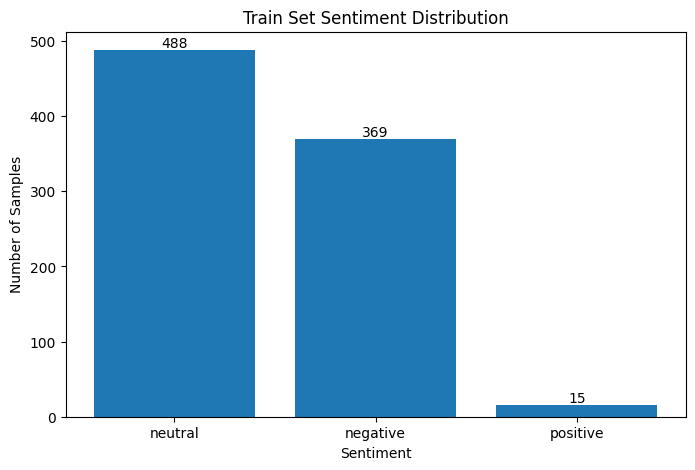


Val Set Sentiment Distribution class distribution:
customer_sentiment
neutral     54
negative    41
positive     2
Name: count, dtype: int64


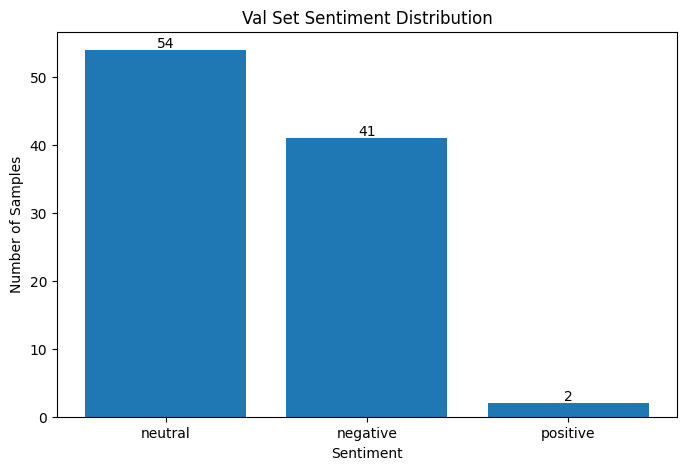


Test Set Sentiment Distribution class distribution:
customer_sentiment
negative    10
neutral     10
positive    10
Name: count, dtype: int64


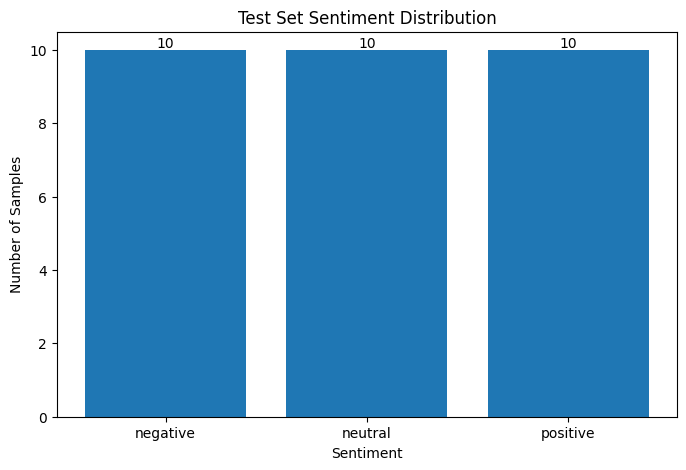

In [30]:
import re
import pandas as pd

# Reload clean copies if needed
train_split_df = pd.read_csv(f"{base_path}/train_split.csv")
val_split_df = pd.read_csv(f"{base_path}/val_split.csv")
test_df = pd.read_csv(f"{base_path}/test.csv")

def clean_conversation(text):
    # Convert to string
    text = str(text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

def preprocess_dataframe(df, text_col="conversation", label_col="customer_sentiment"):
    df = df.copy()

    # Keep only necessary columns
    df = df[[text_col, label_col]].copy()

    # Drop missing rows
    df = df.dropna(subset=[text_col, label_col])

    # Drop duplicate rows
    df = df.drop_duplicates()

    # Clean text
    df[text_col] = df[text_col].apply(clean_conversation)

    # Encode labels
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    df["label"] = df[label_col].map(label_map)

    return df

train_processed = preprocess_dataframe(train_split_df)
val_processed = preprocess_dataframe(val_split_df)
test_processed = preprocess_dataframe(test_df)

print("Processed train shape:", train_processed.shape)
print("Processed val shape:", val_processed.shape)
print("Processed test shape:", test_processed.shape)

plot_sentiment_distribution(train_processed, "Train Set Sentiment Distribution")
plot_sentiment_distribution(val_processed, "Val Set Sentiment Distribution")
plot_sentiment_distribution(test_processed, "Test Set Sentiment Distribution")

In [28]:
train_processed.to_csv(f"{base_path}/train_processed.csv", index=False)
val_processed.to_csv(f"{base_path}/val_processed.csv", index=False)
test_processed.to_csv(f"{base_path}/test_processed.csv", index=False)

print("Processed CSV files saved.")

Processed CSV files saved.
